<a href="https://colab.research.google.com/github/Jtuaz/Projects-Portfolio-/blob/main/Bone_Fracture_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive
GPU available: True
Device name: NVIDIA L4
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/BoneFractureYolo8/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, 

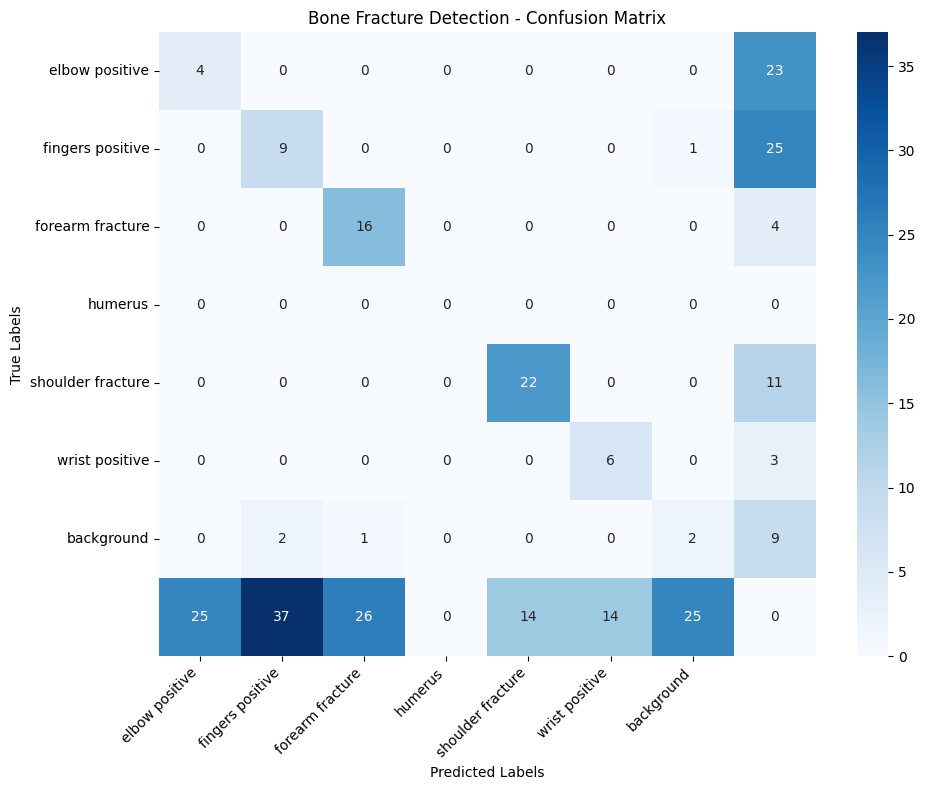

In [2]:
# Install Ultralytics and dependencies
!pip install -q ultralytics matplotlib seaborn scikit-learn

from google.colab import drive
drive.mount('/content/drive')

import torch
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device name: {torch.cuda.get_device_name(0)}")

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from ultralytics import YOLO

# Initialize the YOLOv8 model
MODEL = YOLO('yolov8n.pt')

def main():
    # Load the YOLOv8 model
    MODEL = YOLO('yolov8n.pt')

    # Define paths and parameters
    DATA = '/content/drive/MyDrive/BoneFractureYolo8/data.yaml'
    NUMBER_OF_EPOCHS = 100
    BATCH_SIZE = 32
    TRAINING_SESSION_NAME = 'train3'
    NUMNER_OF_WORKERS = 2

    # Start training
    MODEL.train(
        data=DATA,
        epochs=NUMBER_OF_EPOCHS,
        batch=BATCH_SIZE,
        name=TRAINING_SESSION_NAME,
        workers=NUMNER_OF_WORKERS,
        optimizer='AdamW',
        lr0=0.001,
        save=True
    )

    # Evaluate the model on the validation dataset
    RESULTS = MODEL.val(data=DATA)

    # Extract confusion matrix array computed by YOLO (Shape: [num_classes + 1, num_classes + 1])
    CONFUSION_MATRIX = RESULTS.confusion_matrix.matrix

    # Class names including background (YOLO adds background as the last index)
    CLASS_NAMES = [
        'elbow positive', 'fingers positive', 'forearm fracture',
        'humerus', 'shoulder fracture', 'wrist positive', 'background'
    ]

    # Plot the confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        CONFUSION_MATRIX,
        annot=True,
        fmt=".0f",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Bone Fracture Detection - Confusion Matrix")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('/content/confusion_matrix_bone_fracture.png')
    plt.show()

if __name__ == '__main__':
    main()